<a href="https://colab.research.google.com/github/CatCan55/Non-Boolean-Quantum-Amplitude-Amplification/blob/main/Project_2_Catherine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install qiskit # needed in colab
%pip install pylatexenc
import pylatexenc

from qiskit import QuantumCircuit, QuantumRegister, AncillaRegister
from qiskit.quantum_info import Operator, Statevector
from qiskit.circuit import barrier


import numpy as np
import sympy as sp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=d3e376dd7814d43989fcab8bd5bb47d0f39a95bcdf5a5a46a236e0377856050e
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


Non-boolean amplitude amplification algorithm

1. initialize
2. for k:= 1 to K do
3. if k is odd then
4. update with U_phi
5. else
6. update with U_phi^adj
7. end if
8. end for
9. Measure the ancilla in the 0/1 basis.


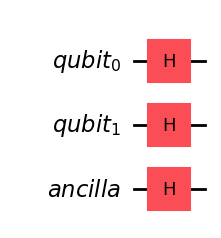

In [6]:
num_qubits = 2
qubit = QuantumRegister(num_qubits, 'qubit')
ancilla = AncillaRegister(1, 'ancilla')

circuit_1 = QuantumCircuit(qubit, ancilla)

# first we initialize, taking A_0 = H here
circuit_1.h(qubit)
circuit_1.h(ancilla)

display(circuit_1.draw('mpl'))

Apply U_phi when k is odd. Apply U_phi_adj when k is even.

In [7]:
N = 2 ** num_qubits
# Define a function of range [0,1]
def g(x):
    return np.sin(x)**2

# Compute the diagonal entries of the phase oracle matrix.
# These will amplify states, prioritizing when g(x) is closer to 1.
# The possible states for x are 0, 1, ..., N-1.
diagonal_entries = [np.exp(1j * np.pi * g(x)) for x in range(N)]

# Create the diagonal matrix for the phase oracle
diagonal_matrix = np.diag(diagonal_entries)

# Create the phase oracle operator
phase_oracle = Operator(diagonal_matrix)

phase_oracle_adjoint = phase_oracle.adjoint()

sp.Matrix(phase_oracle.data) # Display the matrix with numerical values

Matrix([
[1.0,                                       0,                                       0,                                        0],
[  0, -0.608113415652872 + 0.79385015821816*I,                                       0,                                        0],
[  0,                                       0, -0.85561664414546 + 0.517610044590772*I,                                        0],
[  0,                                       0,                                       0, 0.998043488286989 + 0.0625235594631326*I]])

In [ ]:
# Marker oracle: we alternate applying U_phi and U_phi_adj, to remain within the
# span of the correct basis vectors, for the algorithm to work.
# In other words, for odd iterations we apply U_phi
# For even iterations we apply U_phi_adj
# We set up these two gates, calling them odd_gate and even_gate.



odd_gate = U_phi_circuit.to_gate(label='U_phi')

In [ ]:
# Circuit for the adjoint of U_phi

U_phi_adjoint_circuit = U_phi_circuit.inverse()

In [ ]:
even_gate = U_phi_adjoint_circuit.to_gate(label='U_phi^+')

In [ ]:
q1 = QuantumRegister(2, 'q1')
a1 = AncillaRegister(1, 'a1')
odd_iteration_circuit = QuantumCircuit(q1, a1)
# odd_iteration_circuit.append(odd_gate, [q1[0], a1[0]])
# odd_iteration_circuit.append(diffuser_gate, [q1[0], a1[0]])

# display(odd_iteration_circuit.draw('mpl'))

In [ ]:
q2 = QuantumRegister(2, 'q2')
a2 = AncillaRegister(1, 'a2')
even_iteration_circuit = QuantumCircuit(q2, a2)
# even_iteration_circuit.append(even_gate, [q1[0], a1[0]])
# even_iteration_circuit.append(diffuser_gate, [q1[0], a1[0]])